W ramach pracy należy:
- analizy przeprowadzić osobno dla zmiennej kategoryzowanej i zmiennej numerycznej (obie metody)
- określić częściowe zależności liniowe pomiędzy zmiennymi wyjaśnianymi a wyjaśnianymi. Analizy dokonać poprzez wstępny podział zbioru na mniejsze podzbiory przy pomocy drzew decyzyjnych, a następnie zbadać zależności przy pomocy zespołu (ensemble) modeli liniowych. Należy pamiętać o transformacjach (CART + LS)
- wskazać, które zmienne zachowują się nieliniowo i czy zmiany te są uzasadnione rozkładem tych zmiennych (GAM)
- Wskazać jaka część zakresu zmiennych wpływa na zwyżkę ceny (lub zwiększa prawdpodobieństwo zainteresowania) a jaka obniża te cechy (GAM)
- Przeanalizować i odpowiedzieć na pytanie: Czy wszystkie zmienne wyjaśniające powinny być numeryczne? (co zrobić gdy nie są)

In [93]:
from scipy import stats
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression as ls
from sklearn.linear_model import LogisticRegression as log_reg
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor as TreeReg
from sklearn.tree import DecisionTreeClassifier as DTree

from pygam import LinearGAM, s, f, l
from pygam import LogisticGAM

In [6]:
data = pd.read_csv("dane/zal_hausing.csv")
data.head()

,pietro,izby,powierzchnia,zadrzewienie,autostrada,przemysł,centrum,jezioro,lasy,tramwaj,policja,szkola,cena,zainter
0,0,4,65.10,13.44,3153.81100,63.63961,7366.52600,1384.37700,538.56290,472.70500,2996.06800,1324.84000,4531.49,False
1,3,2,32.70,21.56,8452.07227,134.35030,2818.24414,1601.85046,1471.20703,96.04687,1860.02686,289.87067,1972.32,True
2,0,3,40.98,1.20,6571.53900,89.44272,2269.05800,1264.80200,798.82730,40.31129,734.20030,261.72500,2037.58,True
3,3,2,49.53,0.48,11763.63574,207.00241,5615.26953,5416.94092,236.48466,2214.45825,2338.56787,182.48288,5471.43,False
4,4,3,81.40,21.72,4384.95500,169.18920,2375.39500,3475.80900,2024.84600,317.56890,1301.76800,65.00000,3482.80,True


# Wstępna analiza datasetu

In [2]:
data.describe()

,pietro,izby,powierzchnia,zadrzewienie,autostrada,przemysł,centrum,jezioro,lasy,tramwaj,policja,szkola,cena
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.685000,2.919000,51.285580,10.183840,6271.578879,205.613426,3384.262134,2317.269380,1186.627256,523.115499,1246.816483,368.796227,5071.979760
std,2.225472,0.993693,19.734143,11.252383,2786.915515,171.783014,1803.970943,1138.933408,739.922508,868.910216,960.593873,281.821413,1364.321629
min,0.000000,1.000000,14.200000,0.000000,810.493700,5.000000,217.082900,161.012400,25.000000,5.000000,15.000000,18.027760,1019.740000
25%,1.000000,2.000000,37.300000,1.600000,4262.866000,88.459030,2269.058000,1448.528250,623.758750,131.813850,684.560747,188.679600,4211.425000
50%,2.000000,3.000000,47.660000,7.380000,5709.588000,152.970600,2957.723000,2146.654000,1024.217655,250.923250,977.835600,285.000000,5016.815000
75%,4.000000,4.000000,61.645000,15.170000,7718.775500,287.706125,4404.830265,3042.618160,1650.740250,571.646200,1649.869500,452.312552,5966.722500
max,14.000000,5.000000,164.170000,100.000000,12895.780000,977.714200,11353.160000,5546.090820,2967.090000,6933.866000,7446.409000,2612.953000,9474.400000


In [3]:
data.isna().sum()

pietro          0
izby            0
powierzchnia    0
zadrzewienie    0
autostrada      0
przemysł        0
centrum         0
jezioro         0
lasy            0
tramwaj         0
policja         0
szkola          0
cena            0
zainter         0
dtype: int64

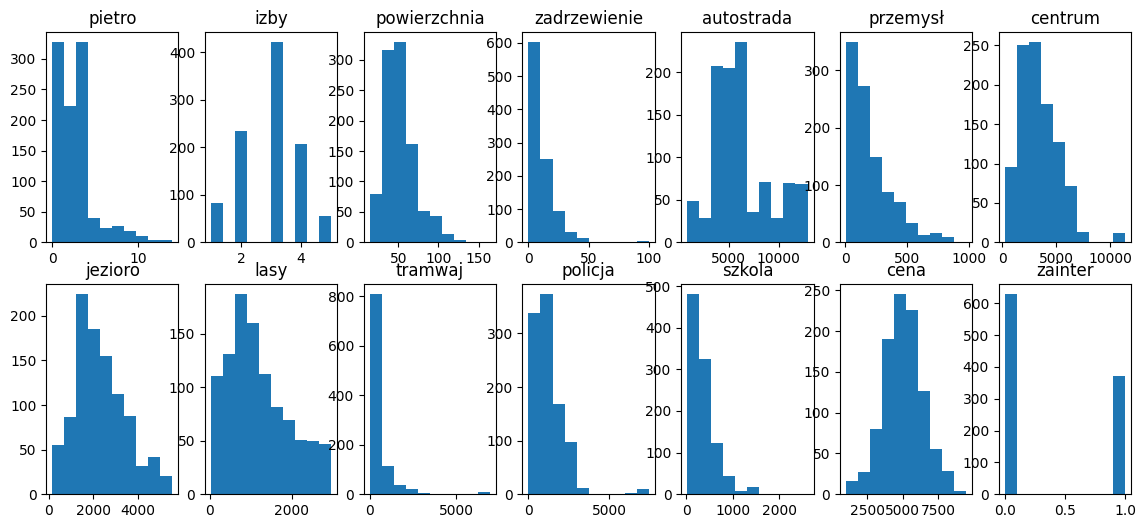

In [10]:
fig,axes = plt.subplots(2, 7, figsize=(14,6))
for column, ax in zip(data.columns, axes.flatten()):
    ax.hist(data[column].astype(float))
    ax.set_title(column)

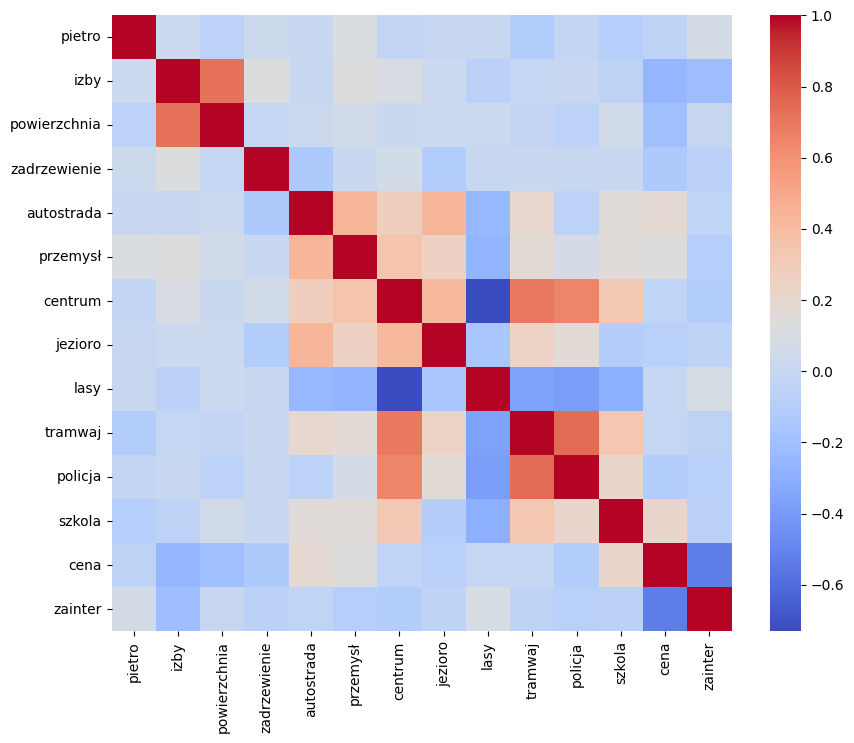

In [73]:
corr = data.corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.show()

# Analiza względem ceny

In [15]:
# drop "zainter" since it would expose super important info about "cena"
X = data.drop(columns=["cena", "zainter"])
y = data["cena"]

# CART + LS

Text(0, 0.5, 'total impurity of leaves')

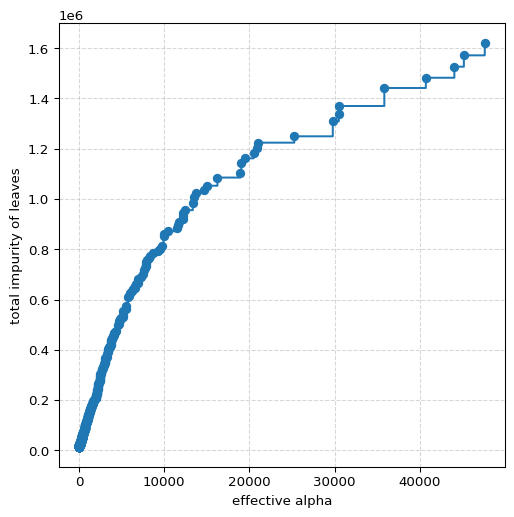

In [50]:
model = TreeReg().fit(X,y)
path = model.cost_complexity_pruning_path(X, y)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
fig, ax = plt.subplots(figsize=(6, 6), dpi=96)
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")

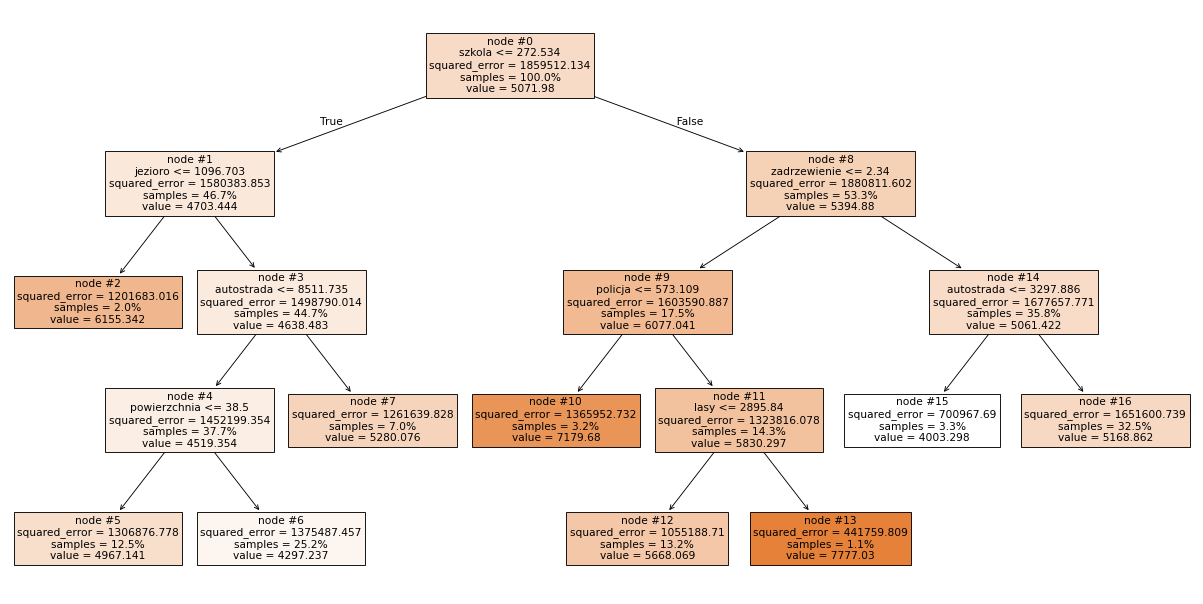

In [54]:
model32 = TreeReg(ccp_alpha=32_000).fit(X, y)
fig, ax = plt.subplots(figsize=(24, 12), dpi=64)
ann = tree.plot_tree(model32, feature_names=X.columns, ax=ax, filled=True, max_depth=5, fontsize=12, proportion=True,
                     node_ids=True)

In [61]:
pd.Series(model32.feature_importances_, index=X.columns).sort_values(ascending=False)

zadrzewienie    0.247725
szkola          0.243143
autostrada      0.152964
policja         0.097282
lasy            0.092275
jezioro         0.089996
powierzchnia    0.076614
pietro          0.000000
izby            0.000000
przemysł        0.000000
centrum         0.000000
tramwaj         0.000000
dtype: float64

### Wnioski z drzewa regresyjnego:

Najważniejszymi zmiennymi w podziałach drzewa są: zadrzewienie, szkola, autostrada; mniej ważne to policja, lasy i jezioro.
Pierwszy podział (w korzeniu) jest wykonywany względem odległości od szkoły (szkola). Sugeruje to, że bliskość szkoły silnie różnicuje poziom cen.
Kolejne podziały dotyczą głównie zmiennych przestrzennych (dostęp do jeziora, drzew, lasu, poziom zadrzewienia, odległość od autostrady/policji).
W danej strukturze podziałów wpływ pietra, izby, centrum, przemysłu i tramwaju jest wtórny wobec wyżej wymienionych odległości, chociaż gra role dla głębszych obszarów drzewa.

In [63]:
coefs = []
leaves = model32.apply(X)
for leave in np.unique(leaves):
    selector = (leaves == leave)
    Xs = X.loc[selector]
    ys = y.loc[selector]
    lmodel = ls().fit(Xs, ys)
    coefs.append(lmodel.coef_)
coefs_df = pd.DataFrame(coefs, columns=X.columns, index=np.unique(leaves)).T
coefs_df

,2,5,6,7,10,12,13,15,16
pietro,244.924070,7.045569,7.245537,-69.108172,-104.261997,14.487742,-2.441046e+02,47.268550,-95.542861
izby,718.870777,-117.557998,-139.975082,-41.662411,-380.886149,-61.796450,-5.012096e+05,33.946394,-65.434302
powierzchnia,-18.203499,4.758492,0.182005,-23.026492,-20.216500,-8.185003,-3.042245e+01,-16.696510,-12.300872
zadrzewienie,-54.637269,-6.930182,10.597765,-27.765274,445.107571,-125.769180,-3.224909e+07,2.184513,-10.656814
autostrada,4.154808,-0.113814,-0.057689,10.916238,0.249024,-0.030972,4.987216e+09,-0.195785,0.028561
przemysł,-0.701434,1.299666,0.071237,-0.758541,-1.507899,0.363927,1.156991e+09,2.187095,0.254249
centrum,-13.744325,0.387091,0.179627,-8.596962,-5.173534,-0.163468,-2.392387e+09,0.493075,-0.006081
jezioro,7.449759,-0.330817,-0.412234,-4.140831,-5.285635,0.234352,-1.663669e+10,0.080358,-0.085207
lasy,-19.650403,0.396390,0.448475,-0.070014,-4.204421,-0.411281,5.477591e+09,-1.315418,-0.240077
tramwaj,10.968333,-0.295733,0.235110,1.743161,-3.473600,-0.231205,1.266820e+09,-1.785255,0.091326


### Wnioski z lokalnych modeli liniowych:

- Otrzymane współczynniki znacząco różnią się pomiędzy liśćmi ==> globalna zależności jest nieliniowa.
Np. dla zadrzewienia w niektórych segmentach współczynnik jest ujemny (obniża przewidywaną cenę), a w innych liściach >0, więc wpływ zadrzewienia na cenę mocno zależy od kontekstu (np. odległości do innych rzeczy: szkoły, jeziora, autostrady).
Podobnie z powierzchnią: w części segmentów ma współczynnik bliski zeru, a w innych jest bardziej wyraźnie ujemna.
- To że znaki i skala współczynników zmieniają się między liśćmi pokazuje, że 1 model liniowy nie mógłby dobrze opisać zależności cena–zmienne wyjaśniające

In [66]:
gam = LinearGAM()
gam.fit(X, y)
gam.summary()

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                    111.0878
Link Function:                     IdentityLink Log Likelihood:                                -14877.9258
Number of Samples:                         1000 AIC:                                            29980.0272
                                                AICc:                                           30008.6112
                                                GCV:                                          1438779.0448
                                                Scale:                                        1154279.5259
                                                Pseudo R-Squared:                                   0.4482
Feature Function                  Lam

/var/folders/1r/k8ndmm417js8lrym5jjwrzp80000gn/T/ipykernel_12187/2369798657.py:3: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  gam.summary()


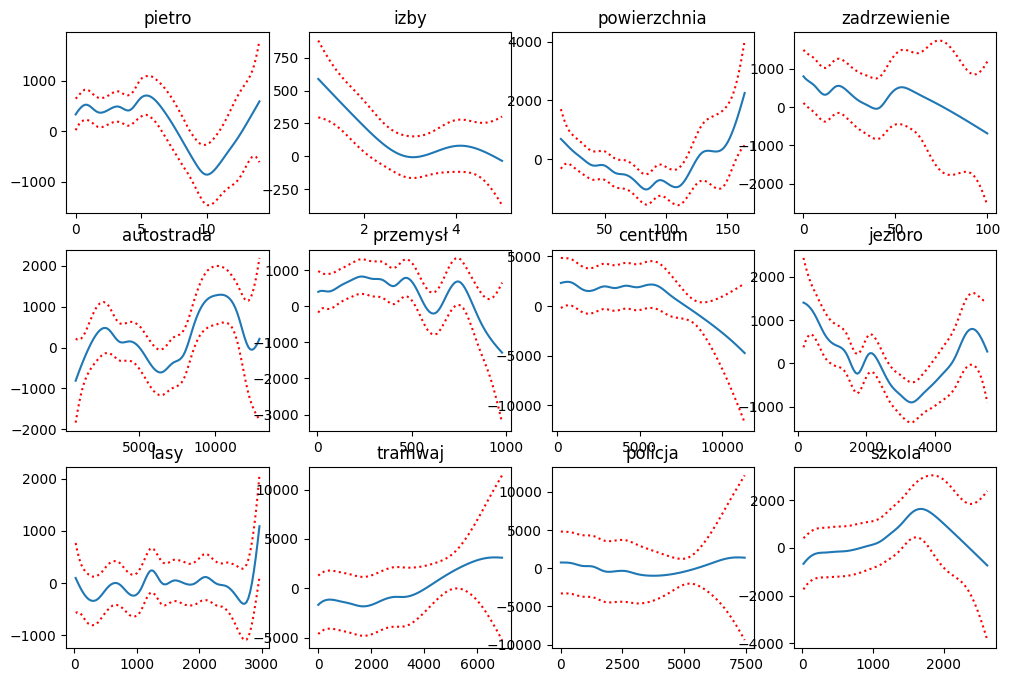

In [69]:
fig, axes = plt.subplots(3,4,figsize=(12,8))
for t, ax in zip(range(len(X.columns)),axes.flatten()):
    XX = gam.generate_X_grid(term=t)
    pdp, confi = gam.partial_dependence(term=t, X=XX, width=0.95)
    ax.plot(XX.T[t],pdp)
    ax.plot(XX.T[t],confi,c="r",ls=":")
    ax.set_title(X.columns[t])

### Wnioski z modelu GAM dla ceny

- LinearGAM ma pseudo R² około 0.45, co oznacza, że nieliniowy związek pomiędzy zmiennymi jest istotny, oraz że duża część powiązań nadał pozostaje niewyjaśniona.
- Dla większości zmiennych efekt jest wyraźnie nieliniowy: krzywe częściowych zależności posiadają lokalne extrema oraz zmieniające się nachylenie ==> globalny model liniowy nie zadziałałby.

Interpretacje dla kilku istotnych cech:
- liczba pokoi silnie podnosi cenę dla kawalerek, natomiast dalszy wzrost liczby pokoi >2 ma dużo słabszy efekt
- powierzchnia ma kształt zbliżony do U: małe i bardzo duże mieszkania są droższe, a średnie metraże są mniej cenne
- jeżeli centrum jest stosunkowo blizko = drożej, jednak w przedziale 5km współczynnik jest prawie taki sam, ale po 5k już dalej = taniej
- autostrada:
  - dla bardzo małych odległości od autostrady cena jest raczej niższa (hałas, zanieczyszczenie);
  - w średnim zakresie odległości (kilka km) pojawia się pierwszy lokalny maksimum, chyba już nie odczuwać hałasu, ale mieszkania mają dobrą dostępność
  - dalej efekt znów maleje, a drugi maksymum może odpowiadać innemu typowi atrakcyjnej lokalizacji

Kształt uzyskanych funkcji częściowych jest zgodny z analizą danych na histogramach: dla wielu zmiennych mamy skupienia danych w wąskich zakresach, co wskazuje na lokalne, a nie globalne efekty liniowe.

# Analiza względem zainteresowania

In [75]:
# cena jest ważna dla analizy zaineresowań
X = data.drop(columns=["zainter"])
y = data["zainter"]

# CART + LS

Text(0, 0.5, 'total impurity of leaves')

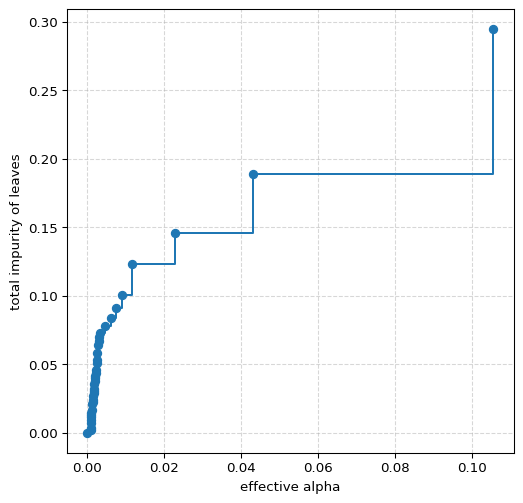

In [81]:
model = DTree().fit(X,y)
path = model.cost_complexity_pruning_path(X, y)
ccp_alphas, impurities = path.ccp_alphas, path.impurities
fig, ax = plt.subplots(figsize=(6, 6), dpi=96)
ax.plot(ccp_alphas[:-1], impurities[:-1], marker="o", drawstyle="steps-post")
ax.grid(True, linestyle="--", alpha=0.5)
ax.set_xlabel("effective alpha")
ax.set_ylabel("total impurity of leaves")

[Text(0.4444444444444444, 0.9, 'node #0\ncena <= 4172.195\ngini = 0.467\nsamples = 100.0%\nvalue = [0.628, 0.372]\nclass = False'),
 Text(0.2222222222222222, 0.7, 'node #1\ncena <= 3900.38\ngini = 0.177\nsamples = 23.5%\nvalue = [0.098, 0.902]\nclass = True'),
 Text(0.3333333333333333, 0.8, 'True  '),
 Text(0.1111111111111111, 0.5, 'node #2\ngini = 0.0\nsamples = 16.9%\nvalue = [0.0, 1.0]\nclass = True'),
 Text(0.3333333333333333, 0.5, 'node #3\npolicja <= 1485.383\ngini = 0.454\nsamples = 6.6%\nvalue = [0.348, 0.652]\nclass = True'),
 Text(0.2222222222222222, 0.3, 'node #4\ngini = 0.184\nsamples = 3.9%\nvalue = [0.103, 0.897]\nclass = True'),
 Text(0.4444444444444444, 0.3, 'node #5\ngini = 0.417\nsamples = 2.7%\nvalue = [0.704, 0.296]\nclass = False'),
 Text(0.6666666666666666, 0.7, 'node #6\nizby <= 1.5\ngini = 0.331\nsamples = 76.5%\nvalue = [0.791, 0.209]\nclass = False'),
 Text(0.5555555555555556, 0.8, '  False'),
 Text(0.5555555555555556, 0.5, 'node #7\ngini = 0.0\nsamples = 7.6%

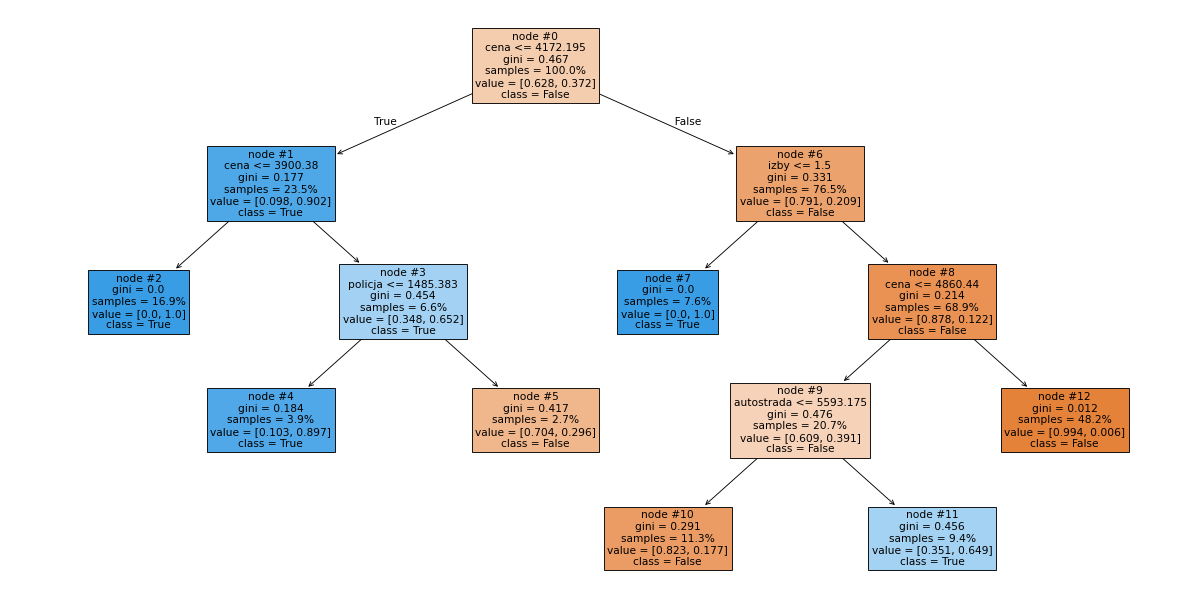

In [90]:
clf_pruned = DTree(ccp_alpha=0.01, random_state=42).fit(X, y)

fig, ax = plt.subplots(figsize=(24, 12), dpi=64)
tree.plot_tree(
    clf_pruned,
    feature_names=X.columns,
    class_names=['False', 'True'],
    filled=True,
    max_depth=5,
    fontsize=12,
    proportion=True,
    node_ids=True,
    ax=ax,
)

In [91]:
pd.Series(clf_pruned.feature_importances_, index=X.columns).sort_values(ascending=False)

cena            0.618767
izby            0.287549
autostrada      0.062271
policja         0.031413
pietro          0.000000
powierzchnia    0.000000
zadrzewienie    0.000000
przemysł        0.000000
centrum         0.000000
jezioro         0.000000
lasy            0.000000
tramwaj         0.000000
szkola          0.000000
dtype: float64

### Wnioski z drzewa regresyjnego:
- najważniejszym predyktorem zainteresowania jak i myśliliśmy jest cena
- izby jest drugim kluczowym czynnikiem
- autostrada i policja mają coraz mniejszy, ale być może zauważalny wpływ
- inne zmienne przestrzenne nie zostały wykorzystane w podziałach, pierwszą która się pojawi przy zwiąkszeniu drzewa będzie szkoła, ale też nie będzie jakoś bardzo istotna

In [105]:
logits = []
leaves = clf_pruned.apply(X)
for leave in np.unique(leaves):
    selector = (leaves == leave)
    Xs = X.loc[selector]
    ys = y.loc[selector]

    if ys.nunique() == 1:
        print(f"Leaf {leave} ma zainteresowanie {ys.iloc[0]}")
        logits.append(np.zeros(len(X.columns)).data)
        continue

    lmodel = log_reg().fit(Xs, ys)
    logits.append(lmodel.coef_[0])
logits_df = pd.DataFrame(logits, columns=X.columns, index=np.unique(leaves)).T
logits_df

Leaf 2 ma zainteresowanie True
Leaf 7 ma zainteresowanie True


/Users/timbarvenov/Documents/uam/sem1/uczenie_glebokie_all/uczenie_glebokie/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Users/timbarvenov/Documents/uam/sem1/uczenie_glebokie_all/uczenie_glebokie/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the d

,2,4,5,7,10,11,12
pietro,0.0,0.011297,-0.012274,0.0,-0.004134,-0.000144,-0.000541
izby,0.0,-0.025001,-0.004661,0.0,-0.013747,-0.006278,-0.004277
powierzchnia,0.0,-0.673585,-0.074090,0.0,-0.110330,-0.082028,-0.071783
zadrzewienie,0.0,0.079683,0.017680,0.0,-0.077656,-0.060470,-0.045527
autostrada,0.0,0.008424,0.023586,0.0,0.000904,0.000713,0.001201
przemysł,0.0,0.056731,0.082178,0.0,0.007333,0.012700,-0.004345
centrum,0.0,-0.028404,0.051858,0.0,0.000188,-0.000138,0.000507
jezioro,0.0,0.017912,0.065451,0.0,-0.000196,-0.002873,-0.000933
lasy,0.0,-0.024815,-0.091855,0.0,-0.000062,0.000601,0.000900
tramwaj,0.0,0.016408,0.017420,0.0,-0.000862,0.003492,-0.002162


### Wnioski z lokalnych modeli logistycznych (CART + LS) dla `zainter`
Powyższa tabela pokazuje, że wpływ zmiennych na prawdopodobieństwo zainteresowania
jest silnie zależny od segmentu wyznaczonego przez drzewo: zależność nieliniową między zainteresowaniem a zmiennymi objaśniającymi.

- W różnych liściach współczynniki dla tej samej zmiennej mają różne znaki i/lub różną skalę.
- powierzchnia: współczynniki są przeważnie ujemne, ale ich wartość różni się między liśćmi.
  W jednych segmentach większy metraż silnie obniża zainteresowanie, w innych wpływ jest dużo słabszy.
  Pokazuje to, że efekt wielkości mieszkania nie jest stały – zależy od poziomu ceny oraz położenia.
- Zmienna `szkola` w jednym z liści (`4`) ma wyraźnie dodatni współczynnik = w tym segmencie bliższa szkoła zwiększa prawdopodobieństwo
  zainteresowania, podczas gdy w innych segmentach efekt jest bliski zeru.

In [107]:
from sklearn.preprocessing import LabelEncoder

LE = LabelEncoder().fit(y)
y = LE.transform(y)
gam = LogisticGAM().fit(X,y)

/Users/timbarvenov/Documents/uam/sem1/uczenie_glebokie_all/uczenie_glebokie/.venv/lib/python3.12/site-packages/pygam/links.py:148: RuntimeWarning: divide by zero encountered in divide
  return dist.levels / (mu * (dist.levels - mu))
/Users/timbarvenov/Documents/uam/sem1/uczenie_glebokie_all/uczenie_glebokie/.venv/lib/python3.12/site-packages/pygam/pygam.py:630: RuntimeWarning: invalid value encountered in multiply
  self.link.gradient(mu, self.distribution) ** 2


In [109]:
yhat = gam.predict(X)
gam.accuracy(X,y)
proba = gam.predict_proba(X)

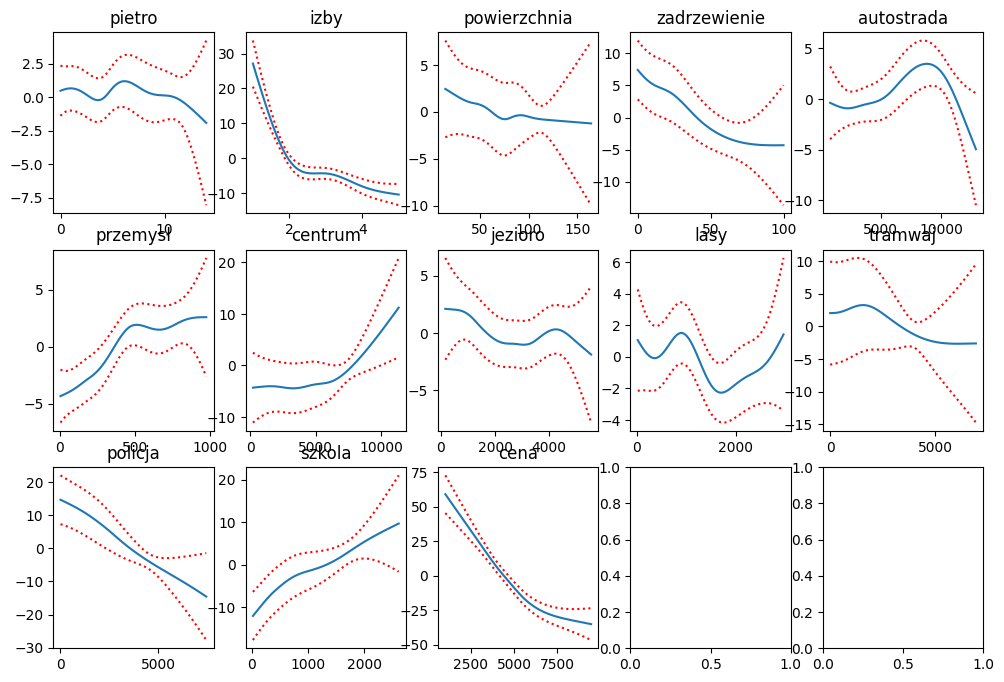

In [112]:
fig, axes = plt.subplots(3, 5,figsize=(12,8))
for term, ax in zip(range(len(X.columns)), axes.flatten()):
    XX = gam.generate_X_grid(term=term)
    pdp, confi = gam.partial_dependence(term=term, X=XX, width=0.95)
    ax.plot(XX.T[term],pdp)
    ax.plot(XX.T[term],confi,c="r",ls=":")
    ax.set_title(X.columns[term])

### Wnioski z LogisticGAM dla zainter

- Częściowe zależności dla części zmiennych mają wyraźnie nieliniowy charakter: krzywe posiadają lokalne ekstrema oraz odcinki o różnym nachyleniu.

Interpretacje dla kilku istotnych cech:
- cena: niskie ceny zdecydowanie zwiększają prawdopodobieństwo zainteresowania (jak już wiemy z drewa wszystko <3900 ma zainteresowanie), a dla wyższych cen szansa gwałtownie spada
- izby pokazuje efekt progowy – kawalerki są najbardziej interesujące, kolejne pokoje już nie są interesujące lub nawet wpływają negatywnie.
- Bliskość policji jest zaletą, dla szkoły odwrotnie.
- zależność od lasów jest bardo nieliniowa, a jednak prawie niewpływająca.
- wykres zależności odległości od centrum najprawdopodobniej jest spowodowany wyższymi cenami w odległości <5000 jak wiemy z analizy zależności centrum-cena.

Kształt uzyskanych funkcji częściowych jest zgodny z analizą danych na histogramach: dla wielu zmiennych mamy skupienia danych w wąskich zakresach, co wskazuje na lokalne, a nie globalne efekty liniowe.

# Czy wszystkie zmienne wyjaśniające powinny być numeryczne? (co zrobić gdy nie są)

Nie, np. najbardziej prawdopodobnym kandydatem na zmienno kategorystyczną jest liczba pokoi: 1/2/3/4/5/dużo. Piętro też może być potencjalnym kandydatem dla zmiany na zmienną kategorystyczną. Odległości dla niektórych cech (np. jezioro) można zamienić na "jest w pobliżu/srednio/daleko"

W GAM dla zmiennych kategorystycznych mamy `f()`. Można też zastosować takie podejścia jak one-hot-encoding.